# Parte 3 - Evaluación del rendimiento con K-Means

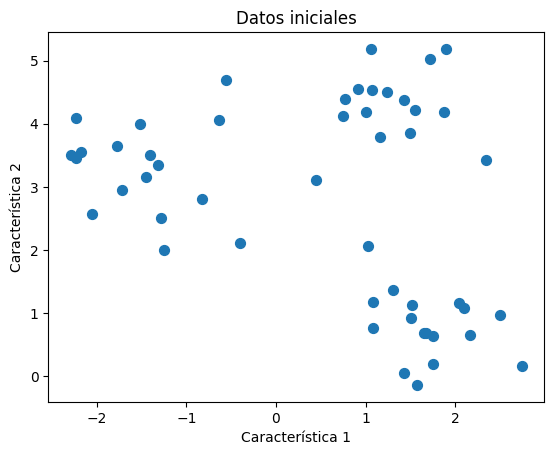

In [ ]:
# Parte 3A - Evaluación con el Método del Codo (Inercia)

# Importamos las bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generación de datos simples para el clustering
np.random.seed(42)
X, y = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=0)

# Visualización inicial de los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos iniciales')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

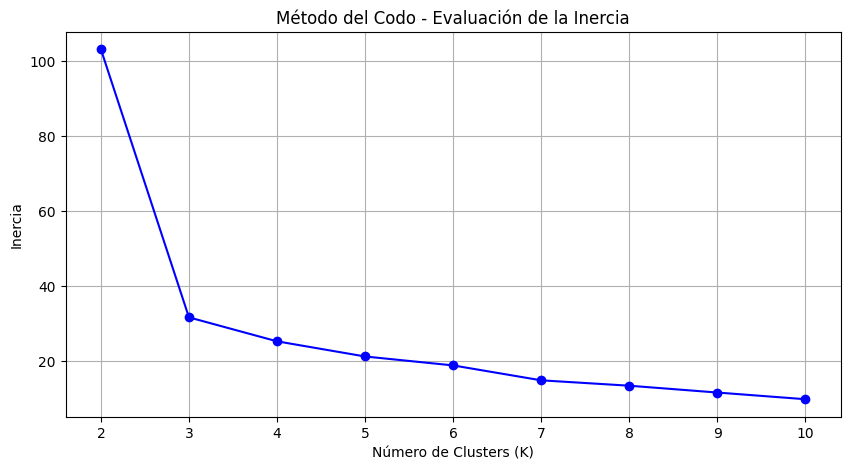

In [ ]:
# Método del Codo: Evaluación de la inercia para diferentes valores de K
inertias = []
K_range = range(2, 11)  # Vamos a probar de 2 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    # Guardamos la inercia (suma de distancias cuadradas al centroide más cercano)
    inertias.append(kmeans.inertia_)

# Visualización del método del Codo
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', label='Inercia')
plt.title('Método del Codo - Evaluación de la Inercia')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

Observamos que la mejor cantidad de clusters es de 3, ya que ahí realiza el quiebre

# Explicación:
* La inercia es la suma de las distancias cuadradas de los puntos al centroide más cercano.
* El método del codo se usa para observar el número óptimo de clusters, donde la disminución de la inercia empieza a ser menos pronunciada.

# Parte 4 - Evaluación con el Coeficiente de Silueta

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

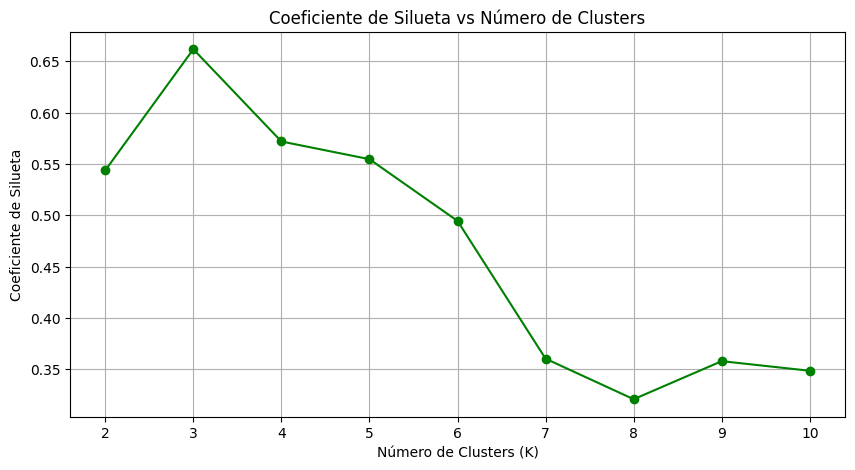

In [ ]:
# Importamos las bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# Evaluación del coeficiente de silueta para diferentes valores de K
silhouette_scores = []
K_range = range(2, 11)  # Vamos a probar de 2 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    # Evaluación del coeficiente de silueta (solo si hay más de 1 cluster)
    if k > 1:
        score = silhouette_score(X, kmeans.labels_)
        silhouette_scores.append(score)

# Visualización del coeficiente de silueta
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'go-', label='Coeficiente de Silueta')  # Ajustamos K_range para que coincida con silhouette_scores
plt.title('Coeficiente de Silueta vs Número de Clusters')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Coeficiente de Silueta')
plt.grid(True)
plt.show()

Podemos observar que el mejor valor de K es 3, ya que es el valor máximo de K

# Explicación:
* El coeficiente de silueta mide qué tan compacto y separado está un cluster en comparación con otros clusters.
* Un valor más alto indica clusters más definidos y separados.

# Parte 5 - Visualización de la Silueta con Yellowbrick

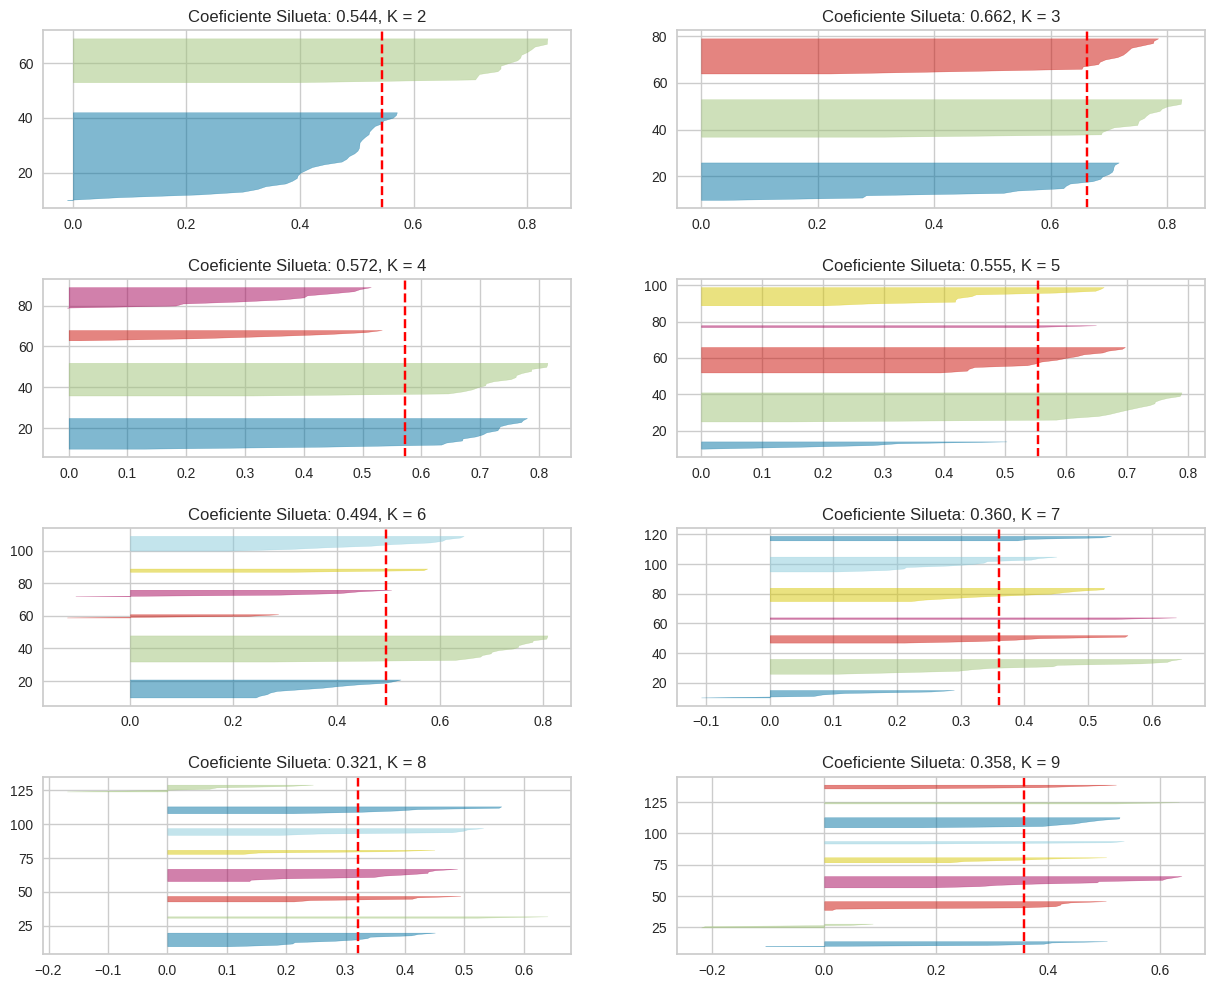

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
# Definimos la figura para múltiples subplots
fig, ax = plt.subplots(4, 2, figsize=(15, 12))  # Ajuste a 4 filas y 2 columnas para 8 gráficos
plt.subplots_adjust(hspace=0.4)  # Ajuste de espacio vertical entre subplots

# Iteramos sobre diferentes valores de K (número de clusters)
for i, k in enumerate(range(2, 10)):
    # Crear la instancia de KMeans para diferentes números de clusters
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)
    km.fit(X)

    # Calcular el coeficiente de silueta
    score = silhouette_score(X, km.labels_, metric='euclidean')

    # Definir posición en el grid
    q, mod = divmod(i, 2)

    # Crear visualización de silueta con Yellowbrick
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q][mod])
    visualizer.set_title(f"Coeficiente Silueta: {score:.3f}, K = {k}")

    # Ajustar la visualización con los datos
    visualizer.fit(X)

plt.show()

# Explicación:
- Utilizamos el coeficiente de silueta para evaluar la calidad de los clusters.
- Generamos 8 subplots, cada uno representando los resultados para diferentes valores de K (de 2 a 9 clusters).
- El título de cada gráfico incluye el valor promedio del coeficiente de silueta para cada K.